In [10]:
import tensorflow as tf
tf.keras.backend.set_floatx('float64')
import numpy as np
import gpflow
from matplotlib import pyplot as plt

# --- Minimal Periodic kernel for GPflow (variance * exp(-2 sin^2(pi d / period) / ell^2))
class PeriodicKernel(gpflow.kernels.Kernel):
    def __init__(self, period=6.0, variance=1.0, lengthscale=0.5, active_dims=None, name="Periodic"):
        super().__init__(active_dims=active_dims, name=name)
        self.period = gpflow.Parameter(period, transform=gpflow.utilities.positive())
        self.variance = gpflow.Parameter(variance, transform=gpflow.utilities.positive())
        self.lengthscale = gpflow.Parameter(lengthscale, transform=gpflow.utilities.positive())

    def K(self, X, X2=None):
        if X2 is None:
            X2 = X
        X = tf.convert_to_tensor(X, dtype=tf.float64)
        X2 = tf.convert_to_tensor(X2, dtype=tf.float64)
        diff = tf.abs(tf.expand_dims(X, -2) - tf.expand_dims(X2, -3))  # [..., N, M, D]
        # if 1D inputs, reduce last dimension
        if diff.shape.rank is not None and diff.shape[-1] == 1:
            diff = tf.squeeze(diff, axis=-1)  # [..., N, M]
        sine_term = tf.sin(np.pi * diff / self.period)
        sq_dist = 2.0 * tf.square(sine_term)
        return self.variance * tf.exp(-sq_dist / (self.lengthscale ** 2))

    def K_diag(self, X):
        X = tf.convert_to_tensor(X, dtype=tf.float64)
        shape = tf.shape(X)[:-1]
        return tf.fill(shape, tf.squeeze(self.variance))


def generate_sample(
    n_points: int = 500,
    sigma_n: float = 0.5,
    heteroskedastic: bool = False,
    percent_output_outliers: float = 0.0,
    add_input_outliers: bool = False,
    n_input_outliers: int = 10,
    input_outlier_spread: float = 20.0,
    seed: int = 10,
    plot: bool = True,
    # NEW: choose how to combine RBF and Periodic: 'sum' or 'product'
    kernel_mode: str = "sum",
    # optional kernel hyperparameters
    period: float = 6.0,
    per_lengthscale: float = 0.5,
    per_variance: float = 1.0,
    rbf_lengthscale: float = 3.0,
    rbf_variance: float = 1.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, gpflow.kernels.Kernel]:
    """
    kernel_mode: 'sum' -> kernel = RBF + Periodic
                 'product' -> kernel = RBF * Periodic (locally-periodic)
    Returns x_obs, y_obs, latent f, and the gpflow kernel object used.
    """
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # --- Construct kernels ---
    periodic = PeriodicKernel(period=period, lengthscale=per_lengthscale, variance=per_variance)
    rbf = gpflow.kernels.SquaredExponential(lengthscales=rbf_lengthscale, variance=rbf_variance)

    kernel_mode = kernel_mode.lower()
    if kernel_mode == "sum":
        kernel = rbf + periodic
    elif kernel_mode == "product":
        kernel = rbf * periodic
    else:
        raise ValueError("kernel_mode must be 'sum' or 'product'")

    # Original input and function
    x = np.linspace(0, 20, n_points).reshape(-1, 1)

    # Build covariance as a NumPy array (convert tensor to numpy for sampling)
    K = kernel.K(tf.convert_to_tensor(x, dtype=tf.float64),
                 tf.convert_to_tensor(x, dtype=tf.float64)).numpy()
    # Numerical jitter for stability
    K += 1e-8 * np.eye(n_points)

    f = np.random.multivariate_normal(
        mean=np.zeros(n_points),
        cov=K
    ).reshape(-1, 1)

    # Noise: homoskedastic or heteroskedastic
    if heteroskedastic:
        # Example: noise increases linearly with x
        noise_scale = sigma_n * (1 + 0.1 * x.squeeze())
    else:
        noise_scale = sigma_n * np.ones(n_points)

    # Draw elementwise noise
    y_obs = f.squeeze() + np.random.normal(loc=0.0, scale=noise_scale)
    y_obs = y_obs.reshape(-1, 1)

    # Apply output outliers
    if percent_output_outliers > 0:
        i_mis = np.random.choice(n_points, int(percent_output_outliers * n_points), replace=False)
        factor = 5.0  # max absolute change
        y_obs[i_mis] += np.random.uniform(-factor, factor, size=(i_mis.size, 1))

    # Apply input outliers
    x_obs = x.copy()
    if add_input_outliers and n_input_outliers > 0:
        replace_idx = np.random.choice(n_points, n_input_outliers, replace=False)
        x_min, x_max = x.min(), x.max()

        x_outliers_low = np.random.uniform(
            low=x_min - input_outlier_spread,
            high=x_min - 0.1 * input_outlier_spread,
            size=(n_input_outliers // 2, 1)
        )
        x_outliers_high = np.random.uniform(
            low=x_max + 0.1 * input_outlier_spread,
            high=x_max + input_outlier_spread,
            size=(n_input_outliers - x_outliers_low.shape[0], 1)
        )
        x_outliers = np.vstack([x_outliers_low, x_outliers_high])
        x_obs[replace_idx] = x_outliers

    # Optional plotting
    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(x, f, 'k--', lw=2, label='true f(x)')
        plt.plot(x_obs, y_obs, 'r.', ms=8, alpha=0.7, label='observed data')
        plt.legend()
        x_min_plot = x.min() - (input_outlier_spread if add_input_outliers else 0)
        x_max_plot = x.max() + (input_outlier_spread if add_input_outliers else 0)
        plt.xlim(x_min_plot, x_max_plot)
        title = f"Generated GP Sample ({'RBF+' if kernel_mode=='sum' else 'RBF*'}Periodic Kernel)"
        if heteroskedastic:
            title += " (Heteroskedastic Noise)"
        else:
            title += " (Homoskedastic Noise)"
        plt.title(title)
        plt.show()

    return x_obs, y_obs, f, kernel


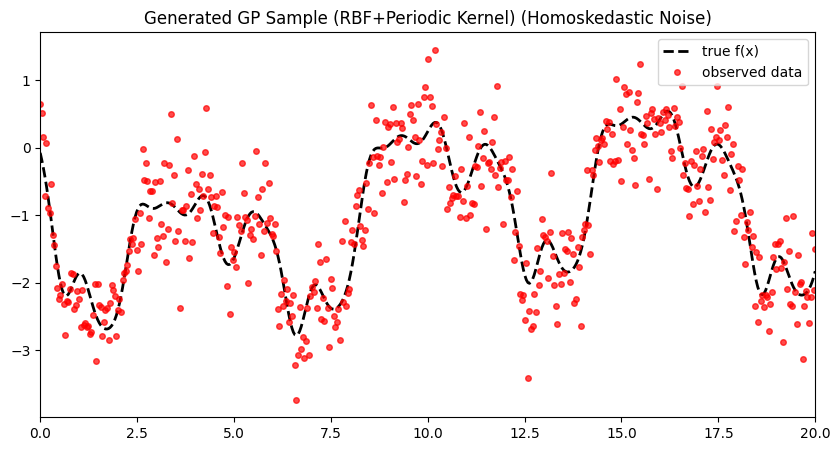

(array([[ 0.        ],
        [ 0.04008016],
        [ 0.08016032],
        [ 0.12024048],
        [ 0.16032064],
        [ 0.2004008 ],
        [ 0.24048096],
        [ 0.28056112],
        [ 0.32064128],
        [ 0.36072144],
        [ 0.4008016 ],
        [ 0.44088176],
        [ 0.48096192],
        [ 0.52104208],
        [ 0.56112224],
        [ 0.6012024 ],
        [ 0.64128257],
        [ 0.68136273],
        [ 0.72144289],
        [ 0.76152305],
        [ 0.80160321],
        [ 0.84168337],
        [ 0.88176353],
        [ 0.92184369],
        [ 0.96192385],
        [ 1.00200401],
        [ 1.04208417],
        [ 1.08216433],
        [ 1.12224449],
        [ 1.16232465],
        [ 1.20240481],
        [ 1.24248497],
        [ 1.28256513],
        [ 1.32264529],
        [ 1.36272545],
        [ 1.40280561],
        [ 1.44288577],
        [ 1.48296593],
        [ 1.52304609],
        [ 1.56312625],
        [ 1.60320641],
        [ 1.64328657],
        [ 1.68336673],
        [ 1

In [11]:
generate_sample()

In [16]:
import traceback
import sys
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
from models import GVI_GP_alpha, GVI_SGPR_alpha, GVI_GP_FI_alpha

# --- SGPR: compute in-sample predictive mean/var from mu_u, Sigma_u ---
def _sgpr_insample_mu_var(model, X):
    """
    Returns numpy arrays (mu, var) at X for your GVI_SGPR_alpha.
    Uses: kernel = ExponentiatedQuadratic(model.variance, model.lengthscale)
    var(x) = k_xx - K_xu K_uu^{-1} K_ux + K_xu K_uu^{-1} Sigma_u K_uu^{-1} K_ux
    """
    import tensorflow_probability as tfp
    k = tfp.math.psd_kernels.ExponentiatedQuadratic(model.variance, model.lengthscale)

    X = tf.convert_to_tensor(X, dtype=tf.float64)
    Z = tf.convert_to_tensor(model.inducing_variable, dtype=tf.float64)
    N_u = int(model.N_u)

    K_uu = k.matrix(Z, Z)
    I_M = tf.eye(N_u, dtype=tf.float64)
    K_uu_inv = model.stable_solve(K_uu, I_M)

    K_xu = k.matrix(X, Z)
    K_ux = tf.transpose(K_xu)
    K_xx = k.matrix(X, X)

    # Sigma_u from structure
    if model.structure == "Diag":
        Sigma_u = tf.linalg.diag(tf.convert_to_tensor(model.Var_q, dtype=tf.float64))
    else:
        L = tf.convert_to_tensor(model.Var_q, dtype=tf.float64)
        Sigma_u = L @ tf.transpose(L)

    # mean & variance
    mu = K_xu @ K_uu_inv @ tf.convert_to_tensor(model.mu_u, dtype=tf.float64)
    A = K_xu @ K_uu_inv
    var = tf.linalg.diag_part(K_xx - A @ K_ux + A @ Sigma_u @ tf.transpose(A))

    mu = tf.squeeze(mu).numpy()
    var = tf.squeeze(var).numpy()
    return mu, var


def eval_and_store_sgpr(model, name, perc, input_o, seed, x, f, results, hetero=False):
    """
    Calls model.predict_ins(), then computes μ, Var in-sample and stores MSE & 95% coverage.
    hetero: bool flag forwarded to eval_and_store_from_mu_var and used in error entries.
    """
    try:
        model.predict_ins()
    except Exception as e:
        print(f"predict_ins() failed for {name} (seed {seed}, perc {perc}, input_o {input_o}): {e}")
        results.append({
            'case_perc': perc,
            'case_input_outliers': bool(input_o),
            'case_heteroskedastic': hetero,
            'seed': int(seed),
            'model': name,
            'mse': np.nan,
            'coverage': np.nan,
            'error': True,
            'error_message': f"predict_ins error: {e}"
        })
        return

    try:
        mu, var = _sgpr_insample_mu_var(model, x)
    except Exception as e:
        print(f"[ERROR] SGPR in-sample μ/Var failed for {name}: {e}")
        results.append({
            'case_perc': perc,
            'case_input_outliers': bool(input_o),
            'case_heteroskedastic': hetero,
            'seed': int(seed),
            'model': name,
            'mse': np.nan,
            'coverage': np.nan,
            'error': True,
            'error_message': f"sgpr mu/var error: {e}"
        })
        return

    # forward hetero flag to the common evaluator
    eval_and_store_from_mu_var(mu, var, name, perc, input_o, seed, f, results, hetero)


# --- Evaluation & storage (consistent schema) ---
def eval_and_store_from_mu_var(mu_arr, var_arr, name, perc, input_o, seed, f, results, hetero):
    """
    Given numpy arrays mu_arr (N,) and var_arr (N,) compute MSE vs f and 95% coverage, append to results.
    """
    mu = np.asarray(mu_arr).reshape(-1)
    var = np.asarray(var_arr).reshape(-1)
    var = np.maximum(var, 0.0)
    std_p = 1.96 * np.sqrt(var)
    upper = mu + std_p
    lower = mu - std_p
    f_arr = np.asarray(f).reshape(-1)
    mse = float(np.mean((mu - f_arr) ** 2))
    coverage = float(np.mean((f_arr >= lower) & (f_arr <= upper)))
    results.append({
        'case_perc': perc,
        'case_input_outliers': bool(input_o),
        'case_heteroskedastic': hetero,   # ✅ include heteroskedastic flag
        'seed': int(seed),
        'model': name,
        'mse': mse,
        'coverage': coverage,
        'error': False,
        'error_message': ""
    })


def eval_and_store(model, name, perc, input_o, seed, x, f, results, hetero):
    """
    Existing model interface: calls model.predict_ins() then reads model.mu_f and model.Sigma_f.
    Keeps backwards compatibility with your GVI models.
    """
    try:
        model.predict_ins()
    except Exception as e:
        print(f"predict_ins() failed for {name} (seed {seed}, perc {perc}, input_o {input_o}): {e}")
        results.append({
            'case_perc': perc,
            'case_input_outliers': bool(input_o),
            'case_heteroskedastic': hetero,   # ✅ add here
            'seed': int(seed),
            'model': name,
            'mse': np.nan,
            'coverage': np.nan,
            'error': True,
            'error_message': f"predict_ins error: {e}"
        })
        return

    # predictive mean
    try:
        mu = np.asarray(tf.squeeze(model.mu_f)).reshape(-1)
    except Exception:
        mu = np.asarray(model.mu_f).reshape(-1)

    # predictive variance
    try:
        Sigma = model.Sigma_f
        try:
            var = np.asarray(tf.linalg.diag_part(Sigma)).reshape(-1)
        except Exception:
            var = np.asarray(Sigma).reshape(-1)
    except Exception:
        try:
            var = np.asarray(model.Sigma_f).reshape(-1)
        except Exception:
            var = np.zeros_like(mu)

    eval_and_store_from_mu_var(mu, var, name, perc, input_o, seed, f, results, hetero)


# --- safe_fit diagnostics wrapper ---
def safe_fit(model_obj, fit_fn, name, perc, input_o, seed, results, hetero):
    """
    fit_fn: callable with no args that runs the fitting.
    """
    print(f"[FITTING] case_perc={perc}, input_o={input_o}, seed={seed}, model={name}", flush=True)
    try:
        fit_fn()
        print(f"[OK] finished {name}", flush=True)
        return True
    except Exception as e:
        print(f"\n[ERROR] fit failed for {name}: {e}", flush=True)
        # record failed run
        results.append({
            'case_perc': perc,
            'case_input_outliers': bool(input_o),
            'case_heteroskedastic': hetero,   # ✅ add here
            'seed': int(seed),
            'model': name,
            'mse': np.nan,
            'coverage': np.nan,
            'error': True,
            'error_message': str(e)
        })
        return False


# --- All create_fit_eval / SGPR / FI helpers ---
def create_fit_eval(name, x, y_obs, base_kernel, perc, input_o, seed, f, results, hetero, fit_method="internal_opt", **model_kwargs):
    try:
        model = GVI_GP_alpha(x, y_obs, base_kernel, **model_kwargs)
    except Exception as e:
        results.append({
            'case_perc': perc,
            'case_input_outliers': bool(input_o),
            'case_heteroskedastic': hetero,
            'seed': int(seed),
            'model': name,
            'mse': np.nan,
            'coverage': np.nan,
            'error': True,
            'error_message': f"construction error: {e}"
        })
        return

    if fit_method == "internal_opt":
        ok = safe_fit(model, model.internal_opt, name, perc, input_o, seed, results, hetero)
    else:
        ok = safe_fit(model, model.pp_alg, name, perc, input_o, seed, results, hetero)

    if ok:
        eval_and_store(model, name, perc, input_o, seed, x, f, results, hetero)


def create_fit_eval_sgpr(name, x, y_obs, inducing, N_u, perc, input_o, seed, f, results,
                         fit_method="internal_opt", loss_type="MSE",
                         structure="Diag", alpha=0.5, test_size=0.1, hetero=False):
    """
    For class GVI_SGPR_alpha: builds, fits (internal_opt or pp_alg), then evaluates in-sample.
    hetero: bool, whether to generate/fit with heteroskedastic noise
    """
    try:
        model = GVI_SGPR_alpha(
            X=x,
            y=y_obs,
            inducing=inducing,
            N_u=N_u,
            loss_type=loss_type,
            structure=structure,
            alpha=alpha,
            test_size=test_size  # note: if your model constructor accepts an explicit hetero flag, add it here
        )
    except Exception as e:
        print(f"[ERROR] constructing SGPR {name} failed: {e}")
        results.append({
            'case_perc': perc,
            'case_input_outliers': bool(input_o),
            'case_heteroskedastic': hetero,
            'seed': int(seed),
            'model': name,
            'mse': np.nan,
            'coverage': np.nan,
            'error': True,
            'error_message': f"construction error: {e}"
        })
        return

    # choose fit method and run
    if fit_method == "internal_opt":
        ok = safe_fit(model, model.internal_opt, name, perc, input_o, seed, results, hetero=hetero)
    else:
        ok = safe_fit(model, model.pp_alg, name, perc, input_o, seed, results, hetero=hetero)

    if ok:
        # pass hetero flag to evaluation so results include it
        eval_and_store_sgpr(model, name, perc, input_o, seed, x, f, results, hetero=hetero)


def create_and_eval_gpr(name, x, y_obs, base_kernel, perc, input_o, seed, f, results, hetero=False):
    """
    Standard exact GP regression for comparison baseline.
    hetero: bool, for storing in results and passing to safe_fit
    """
    try:
        gpr = gpflow.models.GPR(
            data=(x, y_obs),
            kernel=base_kernel,
            mean_function=None
        )
        opt = gpflow.optimizers.Scipy()
        fit_fn = lambda: opt.minimize(gpr.training_loss, gpr.trainable_variables)

        # 🔑 pass hetero to safe_fit
        ok = safe_fit(gpr, fit_fn, name, perc, input_o, seed, results, hetero=hetero)
        if not ok:
            return

        # evaluate
        y_pred, var_pred = gpr.predict_f(x)
        mse = np.mean((y_pred.numpy() - f) ** 2)
        coverage = np.nan  # or compute coverage if desired

        results.append({
            'case_perc': perc,
            'case_input_outliers': bool(input_o),
            'case_heteroskedastic': hetero,
            'seed': int(seed),
            'model': name,
            'mse': mse,
            'coverage': coverage,
            'error': False,
            'error_message': ""
        })
    except Exception as e:
        results.append({
            'case_perc': perc,
            'case_input_outliers': bool(input_o),
            'case_heteroskedastic': hetero,
            'seed': int(seed),
            'model': name,
            'mse': np.nan,
            'coverage': np.nan,
            'error': True,
            'error_message': f"GPR construction/fitting error: {e}"
        })



def create_fit_eval_fi(name, x, y_obs, inducing, perc, input_o, seed, f, results, hetero,
                       fit_method="internal_opt", **kwargs):
    try:
        model = GVI_GP_FI_alpha(X=x, y=y_obs, inducing=inducing, **kwargs)
    except Exception as e:
        results.append({
            'case_perc': perc, 'case_input_outliers': bool(input_o), 'case_heteroskedastic': hetero,
            'seed': int(seed),
            'model': name, 'mse': np.nan, 'coverage': np.nan, 'error': True,
            'error_message': f"construction error: {e}"
        })
        return

    if fit_method == "internal_opt":
        ok = safe_fit(model, model.internal_opt, name, perc, input_o, seed, results, hetero)
    else:
        ok = safe_fit(model, model.internal_opt, name, perc, input_o, seed, results, hetero)

    if ok:
        eval_and_store(model, name, perc, input_o, seed, x, f, results, hetero)


import copy

# --- Main loops ---
cases = [
    [0.0, False, False],   # clean, homoskedastic
]
seeds = [1,2,3,4,5]
N = 400
results = []
# --- Main loops ---
for perc, input_o, hetero in cases:
    for seed in seeds:
        # generate data
        x, y_obs, f, kernel_from_data = generate_sample(
            seed=seed, plot=False,
            add_input_outliers=input_o,
            percent_output_outliers=perc,
            heteroskedastic=hetero,
            n_points=400
        )

        # inducing points
        Z = np.linspace(np.min(x), np.max(x), 50)[:, None]
        inducing_variable = gpflow.Parameter(Z, trainable=False)

        # master kernel
        base_kernel_master = gpflow.kernels.SquaredExponential(
            lengthscales=0.1,
            variance=0.1
        )

        # ✅ Pass hetero=hetero in all calls
        create_fit_eval('predictive_c_f_MSE_calibrated',
                        x=x, y_obs=y_obs, base_kernel=copy.deepcopy(base_kernel_master),
                        perc=perc, input_o=input_o, seed=seed, f=f, results=results,
                        hetero=hetero,
                        fit_method="internal_opt",
                        objective="predictive", inducing=inducing_variable,
                        Sigma_f_structure="c_f", loss_type="MSE")

        create_fit_eval('predictive_inducing_MSE',
                        x=x, y_obs=y_obs, base_kernel=copy.deepcopy(base_kernel_master),
                        perc=perc, input_o=input_o, seed=seed, f=f, results=results,
                        hetero=hetero,
                        fit_method="internal_opt",
                        objective="predictive", inducing=inducing_variable,
                        Sigma_f_structure="inducing", loss_type="MSE")

        create_fit_eval('GVI_inducing_MSE_ppalg',
                        x=x, y_obs=y_obs, base_kernel=copy.deepcopy(base_kernel_master),
                        perc=perc, input_o=input_o, seed=seed, f=f, results=results,
                        hetero=hetero,
                        fit_method="pp_alg",
                        objective="GVI", inducing=inducing_variable,
                        Sigma_f_structure="inducing", loss_type="MSE")

        create_fit_eval('GVI_inducing_likelihood_ppalg',
                        x=x, y_obs=y_obs, base_kernel=copy.deepcopy(base_kernel_master),
                        perc=perc, input_o=input_o, seed=seed, f=f, results=results,
                        hetero=hetero,
                        fit_method="pp_alg",
                        objective="GVI", inducing=inducing_variable,
                        Sigma_f_structure="inducing", loss_type="likelihood")

        create_fit_eval('predictive_c_f_MSE',
                        x=x, y_obs=y_obs, base_kernel=copy.deepcopy(base_kernel_master),
                        perc=perc, input_o=input_o, seed=seed, f=f, results=results,
                        hetero=hetero,
                        fit_method="internal_opt",
                        objective="predictive", inducing=inducing_variable,
                        Sigma_f_structure="c_f", loss_type="MSE")

        create_fit_eval('predictive_c_f_likelihood_calibrated',
                        x=x, y_obs=y_obs, base_kernel=copy.deepcopy(base_kernel_master),
                        perc=perc, input_o=input_o, seed=seed, f=f, results=results,
                        hetero=hetero,
                        fit_method="internal_opt",
                        objective="predictive", inducing=inducing_variable,
                        Sigma_f_structure="c_f", loss_type="likelihood")

        create_fit_eval('predictive_inducing_likelihood_ppalg_2',
                        x=x, y_obs=y_obs, base_kernel=copy.deepcopy(base_kernel_master),
                        perc=perc, input_o=input_o, seed=seed, f=f, results=results,
                        hetero=hetero,
                        fit_method="pp_alg",
                        objective="GVI", inducing=inducing_variable,
                        Sigma_f_structure="inducing", loss_type="likelihood")

        create_fit_eval('predictive_inducing_likelihood',
                        x=x, y_obs=y_obs, base_kernel=copy.deepcopy(base_kernel_master),
                        perc=perc, input_o=input_o, seed=seed, f=f, results=results,
                        hetero=hetero,
                        fit_method="internal_opt",
                        objective="predictive", inducing=inducing_variable,
                        Sigma_f_structure="inducing", loss_type="likelihood")

        create_fit_eval('predictive_c_f_likelihood',
                        x=x, y_obs=y_obs, base_kernel=copy.deepcopy(base_kernel_master),
                        perc=perc, input_o=input_o, seed=seed, f=f, results=results,
                        hetero=hetero,
                        fit_method="internal_opt",
                        objective="predictive", inducing=inducing_variable,
                        Sigma_f_structure="c_f", loss_type="likelihood")

        create_fit_eval('GVI_inducing_likelihood',
                        x=x, y_obs=y_obs, base_kernel=copy.deepcopy(base_kernel_master),
                        perc=perc, input_o=input_o, seed=seed, f=f, results=results,
                        hetero=hetero,
                        fit_method="internal_opt",
                        objective="GVI", inducing=inducing_variable,
                        Sigma_f_structure="inducing", loss_type="likelihood")

        create_fit_eval('GVI_c_f_likelihood',
                        x=x, y_obs=y_obs, base_kernel=copy.deepcopy(base_kernel_master),
                        perc=perc, input_o=input_o, seed=seed, f=f, results=results,
                        hetero=hetero,
                        fit_method="internal_opt",
                        objective="GVI", inducing=inducing_variable,
                        Sigma_f_structure="c_f", loss_type="likelihood")

        create_fit_eval('GVI_c_f_calibrating_likelihood',
                        x=x, y_obs=y_obs, base_kernel=copy.deepcopy(base_kernel_master),
                        perc=perc, input_o=input_o, seed=seed, f=f, results=results,
                        hetero=hetero,
                        fit_method="internal_opt",
                        objective="GVI", inducing=inducing_variable,
                        c_f_calibrating=True,
                        Sigma_f_structure="c_f", loss_type="likelihood")

        create_fit_eval('GVI_inducing_MSE',
                        x=x, y_obs=y_obs, base_kernel=copy.deepcopy(base_kernel_master),
                        perc=perc, input_o=input_o, seed=seed, f=f, results=results,
                        hetero=hetero,
                        fit_method="internal_opt",
                        objective="GVI", inducing=inducing_variable,
                        Sigma_f_structure="inducing", loss_type="MSE")

        create_fit_eval('GVI_c_f_MSE',
                        x=x, y_obs=y_obs, base_kernel=copy.deepcopy(base_kernel_master),
                        perc=perc, input_o=input_o, seed=seed, f=f, results=results,
                        hetero=hetero,
                        fit_method="internal_opt",
                        objective="GVI", inducing=inducing_variable,
                        Sigma_f_structure="c_f", loss_type="MSE")

        # --- SGPR, FI etc. don’t take a base_kernel directly ---
        create_fit_eval_sgpr(
            'GVI_SGPR_alpha_tri',
            x=x, y_obs=y_obs,
            inducing=inducing_variable,
            N_u=int(inducing_variable.shape[0]),
            perc=perc, input_o=input_o, seed=seed, f=f, results=results,
            fit_method="internal_opt",
            loss_type="likelihood",
            structure="Tri",
            alpha=0.5,
            test_size=0.1,
            hetero=hetero
        )

        create_fit_eval_fi(
            'GVI_GP_FI_alpha',
            x=x, y_obs=y_obs,
            inducing=inducing_variable,
            perc=perc, input_o=input_o, seed=seed, f=f, results=results,
            hetero=hetero,
            fit_method="internal_opt",
            alpha=0.5, lengthscale=1.0, variance=1.0
        )

        create_fit_eval(
            'variational_diag_MSE',
            x=x, y_obs=y_obs, base_kernel=copy.deepcopy(base_kernel_master),
            perc=perc, input_o=input_o, seed=seed, f=f, results=results,
            hetero=hetero,
            fit_method="internal_opt",
            objective="variational",
            inducing=inducing_variable,
            Sigma_f_structure="Diag",
            loss_type="MSE"
        )

        # --- Standard exact GPR (comparison baseline) ---
        create_and_eval_gpr(
            'GPR_exact',
            x, y_obs, copy.deepcopy(base_kernel_master),
            perc, input_o, seed, f, results, hetero=hetero
        )


# --- After loops: assemble results and show summary ---
df = pd.DataFrame(results)
print("\nRaw results rows:", len(df))
print("Columns in results:", df.columns.tolist())

# Ensure expected columns exist
expected_cols = ['case_perc', 'case_input_outliers', 'case_heteroskedastic', 'seed', 'model', 'mse', 'coverage', 'error', 'error_message']
for c in expected_cols:
    if c not in df.columns:
        df[c] = np.nan

# Convert types when sensible
df['case_input_outliers'] = df['case_input_outliers'].astype(bool, errors='ignore')
df['seed'] = pd.to_numeric(df['seed'], errors='coerce')

# Exclude failed runs for numeric summary
# Exclude failed runs for numeric summary
numeric_df = df[df['error'].fillna(False) == False].copy()

if numeric_df.shape[0] == 0:
    print("No successful runs to summarize (all failed). Showing raw results instead:")
    print(df.to_string())
else:
    # add readable heteroskedastic/homoskedastic label
    numeric_df['hetero_label'] = np.where(numeric_df['case_heteroskedastic'],
                                          'heteroskedastic', 'homoskedastic')

    # Group by now includes hetero_label so summary differentiates the two cases
    summary = numeric_df.groupby(
        ['case_perc', 'case_input_outliers', 'hetero_label', 'model']
    ).agg(
        mse_mean=('mse', 'mean'),
        mse_std=('mse', 'std'),
        coverage_mean=('coverage', 'mean'),
        coverage_std=('coverage', 'std'),
        n=('mse', 'count')
    ).reset_index()

    pd.set_option('display.float_format', lambda x: f"{x:.4f}")
    print("\nSUMMARY (successful runs):")
    # sort so heteroskedastic cases are next to their homoskedastic counterparts
    print(summary.sort_values(['case_perc', 'case_input_outliers', 'model', 'hetero_label']).to_string(index=False))

# Print failed runs (if any)
failures = df[df['error'].fillna(False) == True]
if len(failures):
    # include heteroskedastic flag for failures too
    print("\nFAILED RUNS SUMMARY:")
    print(failures[['case_perc', 'case_input_outliers', 'case_heteroskedastic', 'seed', 'model', 'error_message']].to_string(index=False))



[FITTING] case_perc=0.0, input_o=False, seed=1, model=predictive_c_f_MSE_calibrated
[OK] finished predictive_c_f_MSE_calibrated
[FITTING] case_perc=0.0, input_o=False, seed=1, model=predictive_inducing_MSE
[OK] finished predictive_inducing_MSE
[FITTING] case_perc=0.0, input_o=False, seed=1, model=GVI_inducing_MSE_ppalg
[OK] finished GVI_inducing_MSE_ppalg
[FITTING] case_perc=0.0, input_o=False, seed=1, model=GVI_inducing_likelihood_ppalg
[OK] finished GVI_inducing_likelihood_ppalg
[FITTING] case_perc=0.0, input_o=False, seed=1, model=predictive_c_f_MSE
[OK] finished predictive_c_f_MSE
[FITTING] case_perc=0.0, input_o=False, seed=1, model=predictive_c_f_likelihood_calibrated
[OK] finished predictive_c_f_likelihood_calibrated
[FITTING] case_perc=0.0, input_o=False, seed=1, model=predictive_inducing_likelihood_ppalg_2
[OK] finished predictive_inducing_likelihood_ppalg_2
[FITTING] case_perc=0.0, input_o=False, seed=1, model=predictive_inducing_likelihood
[OK] finished predictive_inducing_l

2025-08-28 17:12:44.599594: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.
	 [[{{function_node __forward_train_step_11104814}}{{node MatrixInverse_1}}]]


[OK] finished GVI_inducing_MSE_ppalg
[FITTING] case_perc=0.0, input_o=False, seed=3, model=GVI_inducing_likelihood_ppalg
[OK] finished GVI_inducing_likelihood_ppalg
[FITTING] case_perc=0.0, input_o=False, seed=3, model=predictive_c_f_MSE
[OK] finished predictive_c_f_MSE
[FITTING] case_perc=0.0, input_o=False, seed=3, model=predictive_c_f_likelihood_calibrated
[OK] finished predictive_c_f_likelihood_calibrated
[FITTING] case_perc=0.0, input_o=False, seed=3, model=predictive_inducing_likelihood_ppalg_2
[OK] finished predictive_inducing_likelihood_ppalg_2
[FITTING] case_perc=0.0, input_o=False, seed=3, model=predictive_inducing_likelihood
[OK] finished predictive_inducing_likelihood
[FITTING] case_perc=0.0, input_o=False, seed=3, model=predictive_c_f_likelihood
[OK] finished predictive_c_f_likelihood
[FITTING] case_perc=0.0, input_o=False, seed=3, model=GVI_inducing_likelihood
[OK] finished GVI_inducing_likelihood
[FITTING] case_perc=0.0, input_o=False, seed=3, model=GVI_c_f_likelihood
[O

2025-08-28 17:15:27.593995: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.
	 [[{{function_node __forward_train_step_11426856}}{{node MatrixInverse_1}}]]


[OK] finished GPR_exact
[FITTING] case_perc=0.0, input_o=False, seed=4, model=predictive_c_f_MSE_calibrated
[OK] finished predictive_c_f_MSE_calibrated
[FITTING] case_perc=0.0, input_o=False, seed=4, model=predictive_inducing_MSE
[OK] finished predictive_inducing_MSE
[FITTING] case_perc=0.0, input_o=False, seed=4, model=GVI_inducing_MSE_ppalg
[OK] finished GVI_inducing_MSE_ppalg
[FITTING] case_perc=0.0, input_o=False, seed=4, model=GVI_inducing_likelihood_ppalg
[OK] finished GVI_inducing_likelihood_ppalg
[FITTING] case_perc=0.0, input_o=False, seed=4, model=predictive_c_f_MSE
[OK] finished predictive_c_f_MSE
[FITTING] case_perc=0.0, input_o=False, seed=4, model=predictive_c_f_likelihood_calibrated
[OK] finished predictive_c_f_likelihood_calibrated
[FITTING] case_perc=0.0, input_o=False, seed=4, model=predictive_inducing_likelihood_ppalg_2
[OK] finished predictive_inducing_likelihood_ppalg_2
[FITTING] case_perc=0.0, input_o=False, seed=4, model=predictive_inducing_likelihood
[OK] finish

In [17]:
summary

,case_perc,case_input_outliers,hetero_label,model,mse_mean,mse_std,coverage_mean,coverage_std,n
0,0.0000,False,homoskedastic,GPR_exact,0.0348,0.0239,NaN,NaN,5
1,0.0000,False,homoskedastic,GVI_GP_FI_alpha,0.2415,0.0133,0.4900,0.0469,5
2,0.0000,False,homoskedastic,GVI_SGPR_alpha_tri,0.0278,0.0041,0.8730,0.0472,5
3,0.0000,False,homoskedastic,GVI_c_f_MSE,0.0497,0.0250,0.9340,0.0905,5
4,0.0000,False,homoskedastic,GVI_c_f_calibrating_likelihood,0.0245,0.0028,0.9255,0.0413,5
5,0.0000,False,homoskedastic,GVI_c_f_likelihood,0.0245,0.0028,0.9350,0.0390,5
6,0.0000,False,homoskedastic,GVI_inducing_MSE,0.0705,0.0136,0.9260,0.0569,5
7,0.0000,False,homoskedastic,GVI_inducing_MSE_ppalg,0.0705,0.0136,0.9260,0.0569,5
8,0.0000,False,homoskedastic,GVI_inducing_likelihood,0.0329,0.0115,0.8860,0.0569,5
9,0.0000,False,homoskedastic,GVI_inducing_likelihood_ppalg,0.0335,0.0110,0.8820,0.0525,5
